# Synchronization Analysis With Recurrence Plots

We are looking for a time series which shows generalized synchronization of the form $x(t) = F(y(t))$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

from tqdm import tqdm

# we can use the pyunicorn classes for all types of recurrence plots for convenience
from pyunicorn.timeseries.recurrence_plot import RecurrencePlot
from pyunicorn.timeseries.cross_recurrence_plot import CrossRecurrencePlot
from pyunicorn.timeseries.joint_recurrence_plot import JointRecurrencePlot

### Definition Of Roessler And Lorenz System

In [2]:
def roessler(t, XYZ, a, b, c):
    X, Y, Z = XYZ

    dx = -(Y + Z)
    dy = X + a * Y
    dz = b + (X - c) * Z

    return [dx, dy, dz]


def lorenz(t, XYZ, sigma, rho, beta):
    X, Y, Z = XYZ

    dx = sigma * (Y - X)
    dy = X * (rho - Z) - Y
    dz = X * Y - beta * Z

    return [dx, dy, dz]

In [3]:
T = 100
dt = 0.01

np.random.seed(42)
XYZ0 = np.random.rand(3)   

t_span = (0, T)
t_eval = np.arange(0, T, dt)

a = 0.2
b = 0.2
c = 5.7

sol_r = solve_ivp(
    roessler,
    t_span,
    XYZ0,
    t_eval=t_eval,
    args=(a, b, c),
    method="RK45"
)

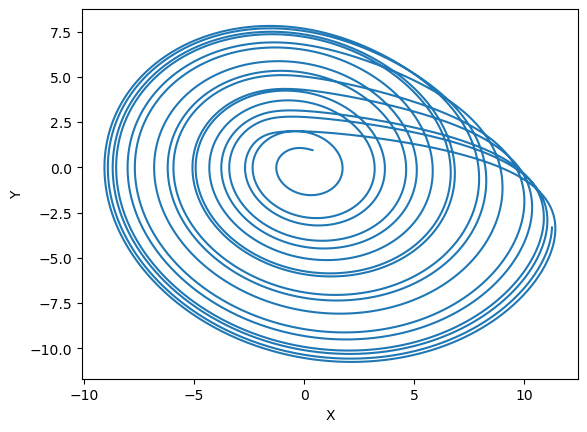

In [4]:
plt.plot(sol_r.y[0], sol_r.y[1])
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [5]:
T = 100
dt = 0.01

np.random.seed(42)
XYZ0 = np.random.rand(3)   

t_span = (0, T)
t_eval = np.arange(0, T, dt)

sigma = 10
rho = 28
beta = 8/3

sol_l = solve_ivp(
    lorenz,
    t_span,
    XYZ0,
    t_eval=t_eval,
    args=(sigma, rho, beta),
    method="RK45"
)

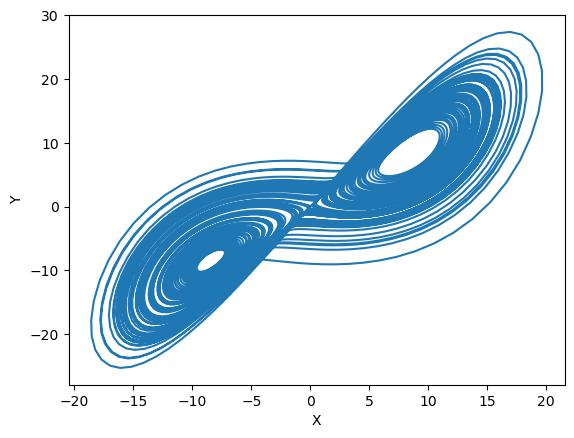

In [6]:
plt.plot(sol_l.y[0], sol_l.y[1])
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [7]:
def coupled_system(t, state, a, b, c, sigma, rho, beta, eps):
    
    x1, y1, z1, x2, y2, z2 = state

    # Roessler (drive)
    dx1 = -(y1 + z1)
    dy1 = x1 + a * y1
    dz1 = b + (x1 - c) * z1

    # Lorenz (response)
    dx2 = sigma * (y2 - x2) + eps * (x1 - x2)
    dy2 = x2 * (rho - z2) - y2
    dz2 = x2 * y2 - beta * z2

    return [dx1, dy1, dz1, dx2, dy2, dz2]

In [8]:
T = 100
dt = 0.1

np.random.seed(42)
XYZ0 = np.random.rand(6)   

t_span = (0, T)
t_eval = np.arange(0, T, dt)

a, b, c = 0.2, 0.2, 5.7        # Roessler
sigma, rho, beta = 10, 28, 8/3 # Lorenz
eps = 0.95                      # coupling strength

sol_c = solve_ivp(
    coupled_system,
    t_span,
    XYZ0,
    t_eval=t_eval,
    args=(a, b, c, sigma, rho, beta, eps),
    method="RK45"
)

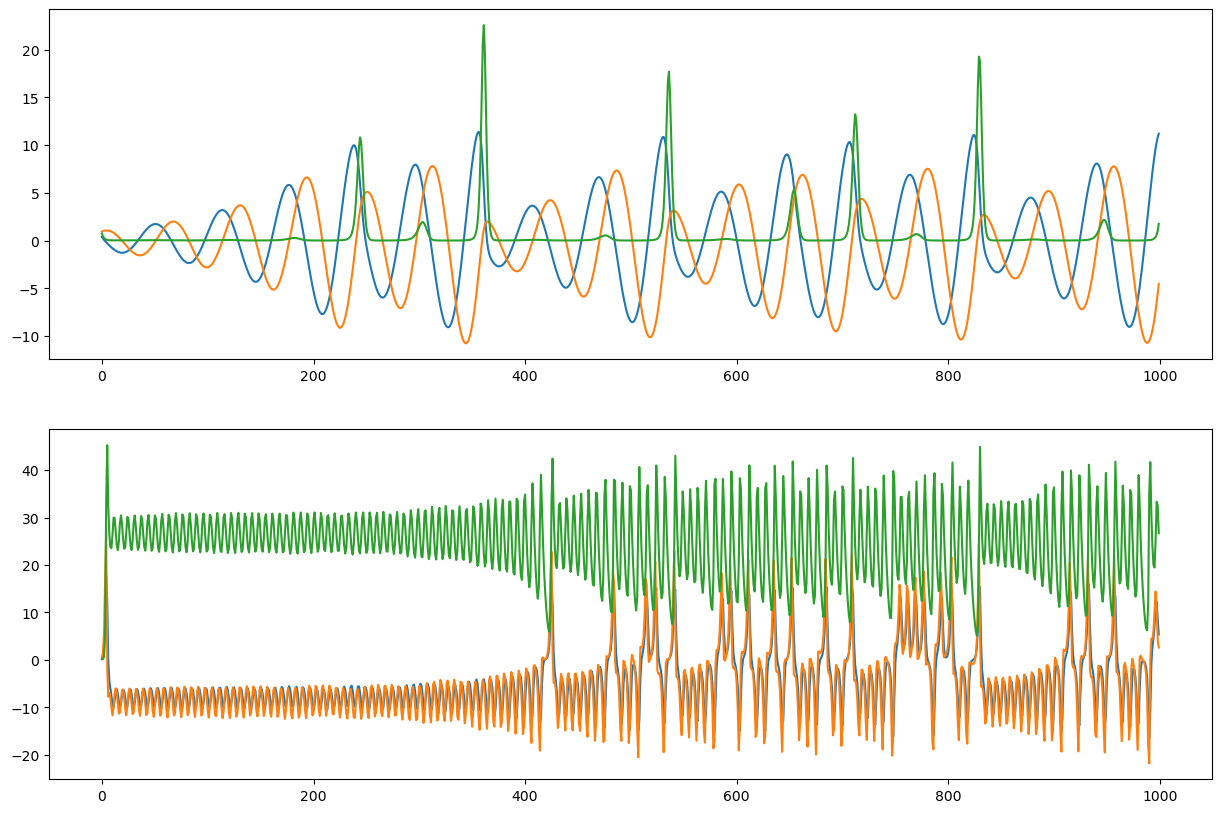

In [9]:
fig, ax = plt.subplots(nrows = 2, figsize=(15, 10))

for ts, label in zip([0, 1, 2], ["R1", "R2", "R3"]):
    ax[0].plot(sol_c.y[ts, :], label=label)

for ts, label in zip([3, 4, 5], ["L1", "L2", "L3"]):
    ax[1].plot(sol_c.y[ts, :], label=label)

plt.show()

In [10]:
epss = np.logspace(-2, 1, 50)

results = {}

for e in tqdm(epss):
    results[e] = solve_ivp(
        coupled_system,
        t_span,
        XYZ0,
        t_eval=t_eval,
        args=(a, b, c, sigma, rho, beta, e),
        method="RK45"
    )

100%|██████████| 50/50 [00:05<00:00,  8.61it/s]


In [15]:
def rr_tau(Rmat, symmetric=False, Rmat2=None, metric="correlation"):

    if symmetric & (Rmat2 is not None):
        counts1 = np.zeros(Rmat.shape[0])
        for i in range(Rmat.shape[0]):
            for (ii, jj) in zip(range(Rmat.shape[0] - i), range(Rmat.shape[0] - i)):
                counts1[i] += Rmat[i + ii, 0 + jj]
            counts1[i] /= (Rmat.shape[0] - i)

        counts2 = np.zeros(Rmat2.shape[0])
        for i in range(Rmat2.shape[0]):
            for (ii, jj) in zip(range(Rmat2.shape[0] - i), range(Rmat2.shape[0] - i)):
                counts2[i] += Rmat2[i + ii, 0 + jj]
            counts2[i] /= (Rmat2.shape[0] - i)

        if metric == "correlation":
            CPR = np.round(np.corrcoef(counts1, counts2)[0, 1], decimals=3)
        elif metric == "hellinger":
            CPR = (1 / np.sqrt(2)) * np.sqrt(np.sum((np.sqrt(counts1) - np.sqrt(counts2)) ** 2))
        elif metric == "jensen_shannon":
            M = 0.5 * (counts1 + counts2)
            CPR = 0.5 * (np.sum(counts1 * np.log(counts1 / M)) + np.sum(counts2 * np.log(counts2 / M)))
        elif metric == "total_variation":
            CPR = 0.5 * np.sum(np.abs(counts1 - counts2))
        elif metric == "wasserstein":
            CPR = np.sum(np.abs(np.cumsum(counts1) - np.cumsum(counts2)))
        elif metric == "bhattacharyya":
            CPR = -np.log(np.sum(np.sqrt(counts1 * counts2)))
        else:
            raise ValueError(f"Unsupported metric: {metric}")

        return {"1": counts1, "2": counts2, "CPR": CPR}
    
    else:
        counts_0 = np.zeros(Rmat.shape[0])
        for i in range(Rmat.shape[0]):
            for (ii, jj) in zip(range(Rmat.shape[0] - i), range(Rmat.shape[0] - i)):
                counts_0[i] += Rmat[i + ii, 0 + jj]
            counts_0[i] /= (Rmat.shape[0] - i)

        counts_1 = np.zeros(Rmat.shape[1])
        for i in range(Rmat.shape[1]):
            for (ii, jj) in zip(range(Rmat.shape[1] - i), range(Rmat.shape[1] - i)):
                counts_1[i] += Rmat[0 + jj, i + ii]
            counts_1[i] /= (Rmat.shape[1] - i)

        CPR = np.round(np.corrcoef(counts_0, counts_1)[0, 1], decimals=3)

        return {"0->1": counts_0, "1->0": counts_1, "CPR": CPR}

In [28]:
keys = []
items = []

for k, res in results.items():

    rr = rr_tau(RecurrencePlot(res.y[0:3, :].T, metric="euclidean", recurrence_rate=0.05).recurrence_matrix(), 
            symmetric=True, 
            Rmat2=RecurrencePlot(res.y[3:6, :].T, metric="euclidean", recurrence_rate=0.05).recurrence_matrix(),
            metric="hellinger")

    keys.append(k)
    items.append(rr["CPR"])

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance 

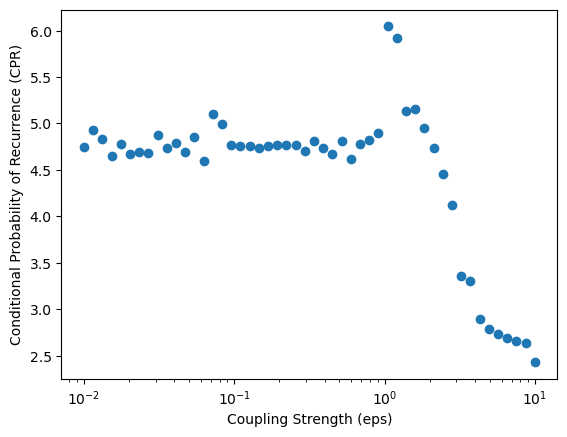

In [29]:
plt.scatter(keys, items)
plt.xlabel("Coupling Strength (eps)")
plt.ylabel("Conditional Probability of Recurrence (CPR)")
plt.xscale("log")
plt.show()

In [30]:
class R_FAN(RecurrencePlot):
    """
    Returns a recurrence matrix based on a fixed number of nearest neighbors N
    """
    def rfan(self, Nn):
        distance = self.distance_matrix(metric="euclidean")
        N = distance.shape[0]

        R_mod = np.zeros((N, N))

        for i in range(N):
            dist = distance[i].copy()
            dist[i] = np.inf  
            idx = np.argsort(dist)[:Nn]
            R_mod[i, idx] = 1

        return R_mod

def jrp(oscillators, sol, Nn, mode="JPR", max_lag=None, plot=False, component=0, test_lag=0):

    if test_lag != 0:
        ts1, ts2 = sol.y[oscillators[0]:oscillators[0]+3, test_lag:].T, sol.y[oscillators[1]*3:oscillators[1]*3+3, :-test_lag].T
    else:
        ts1, ts2 = sol.y[oscillators[0]:oscillators[0]+3].T, sol.y[oscillators[1]*3:oscillators[1]*3+3].T

    N = ts1.shape[0]
    RR = Nn / N
    
    RF1 = R_FAN(ts1, recurrence_rate=0.05, metric="euclidean")
    Rx = RF1.rfan(Nn)
    RF2 = R_FAN(ts2, recurrence_rate=0.05, metric="euclidean")
    Ry = RF2.rfan(Nn)
    
    if mode == "simple":
        RRxy = np.sum(Rx * Ry) / (N*N)
        S = RRxy / RR

        return S
    
    elif mode == "JPR":
        if max_lag is None:
            raise ValueError("max_lag must be specified for JPR mode")

        s_tau = []
        taus = range(-max_lag, max_lag + 1)

        for tau in taus:

            if tau > 0:
                Rx_sub = Rx[:-tau, :-tau]
                Ry_sub = Ry[tau:, tau:]
            elif tau < 0:
                Rx_sub = Rx[-tau:, -tau:]
                Ry_sub = Ry[:tau, :tau]
            else:
                Rx_sub = Rx
                Ry_sub = Ry

            N_eff = Rx_sub.shape[0]

            RRxy_tau = np.sum(Rx_sub * Ry_sub) / (N_eff * N_eff)
            s_tau.append(RRxy_tau / RR)

        s_tau = np.array(s_tau)

        S_max = np.max(s_tau)
        tau_max = taus[np.argmax(s_tau)]

        JPR = (S_max - RR) / (1 - RR)

        if plot:
            fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(30, 10))
            ax[0].plot(range(-max_lag, max_lag+1), s_tau)
            ax[1].plot(ts1[:,component], label="TS1", c="blue")
            ax[1].plot(ts2[:,component], label="TS2 Normal", ls="--", alpha=0.5, c="red")
            ax[1].plot(range(0-tau_max, ts2.shape[0]-tau_max), ts2[:,component], label="TS2 Lagged", c="red")
            plt.legend()
            plt.show()

        return {"tau": tau_max, "JPR": JPR}

    else:
        print("Choose either 'simple' or 'JPR' as mode")

In [31]:
ks = []
jprs = []

for k, res in results.items():

    out = jrp(oscillators=(0,1), sol=res, Nn=50, max_lag=100, plot=False, component=1)

    ks.append(k)
    jprs.append(out["JPR"])

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance 

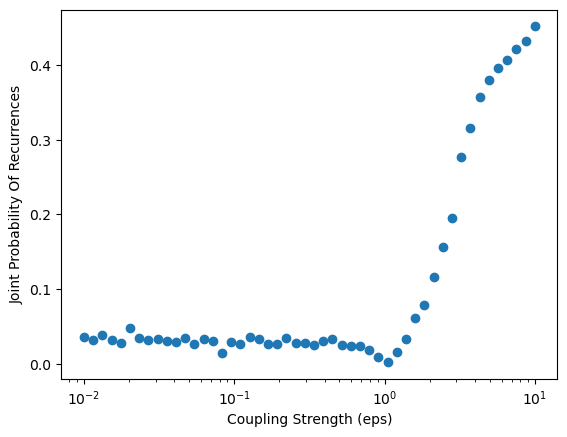

In [32]:
plt.scatter(ks, jprs)
plt.xlabel("Coupling Strength (eps)")
plt.ylabel("Joint Probability Of Recurrences")
plt.xscale("log")
plt.show()